# loading data 

In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.stats import norm
from scipy.optimize import curve_fit

In [2]:
# defining tags
tags = [
#USEFUL DATA:
        "1_23062026O_purewater_left",
        "1_23062026A_purewater_left",
        "2_23062026A_purewater_right",
        "1_24062026_purewater_left",
        "2_24062026_purewater_right"
]

experiment_data = {}  # Master dictionary for all data

for tag in tags:
    experiment_data[tag] = {
        "times": None,
        "temps": None,
        "volume": None
    }

    # Load times
    times_file_path = f'C:/BEP/Times/times_{tag}.txt'
    try:
        experiment_data[tag]["times"] = np.loadtxt(times_file_path, dtype=int)
    except FileNotFoundError:
        print(f"Warning: File not found - {times_file_path}")

    # Load temps
    # Extract base tag (remove volume information)
    base_tag = "_".join(tag.split("_")[:-1])  # Removes last part (e.g., "50microL" or "100microL")
    # Load temperature data
    temp_file_path = f'C:/BEP/Temperatures/temp_{base_tag}.txt'
    try:
        experiment_data[tag]["temps"] = np.loadtxt(temp_file_path, dtype=float)
    except FileNotFoundError:
        print(f"Warning: File not found - {temp_file_path}")

    # Assign volume based on tag
    if "50microL" in tag:
        experiment_data[tag]["volume"] = 50e-6
    elif "100microL" in tag:
        experiment_data[tag]["volume"] = 100e-6
    else:
        experiment_data[tag]["volume"] = 50e-6  # Default is 50 microL

# Print out for verification
for tag, data in experiment_data.items():
    print(f"Experiment: {tag}")
    print(f"  Times: {len(data['times']) if data['times'] is not None else 'Missing'}")
    print(f"  Temps: {len(data['temps']) if data['temps'] is not None else 'Missing'}")
    print(f"  Volume: {data['volume']*1e6} microL\n")

Experiment: 1_23062026O_purewater_left
  Times: 60
  Temps: 3929
  Volume: 50.0 microL

Experiment: 1_23062026A_purewater_left
  Times: 64
  Temps: 3907
  Volume: 50.0 microL

Experiment: 2_23062026A_purewater_right
  Times: 59
  Temps: 3907
  Volume: 50.0 microL

Experiment: 1_24062026_purewater_left
  Times: 65
  Temps: 4246
  Volume: 50.0 microL

Experiment: 2_24062026_purewater_right
  Times: 36
  Temps: 4246
  Volume: 50.0 microL



In [3]:
    """
    Parameters:
    - times_dict: Dictionary of freezing event times {"label": times_array}.
    - temp_dict: Dictionary of temperatures {"label": temp_array}.
    - num_droplets: Total number of droplets.
    - V: Volume in cm³ (e.g., 50e-3 for 50 µl).
    - time_step: time between measurements in seconds
    - labels: List of dataset labels.
    - xlim: Tuple specifying x-axis limits.
    - ylim: Tuple specifying y-axis limits (default: None).
    - colors: color for all experiments
    - names: legend name for all experiments
    - filename: Optional filename to save the plot (default: None).
    """

'\nParameters:\n- times_dict: Dictionary of freezing event times {"label": times_array}.\n- temp_dict: Dictionary of temperatures {"label": temp_array}.\n- num_droplets: Total number of droplets.\n- V: Volume in cm³ (e.g., 50e-3 for 50 µl).\n- time_step: time between measurements in seconds\n- labels: List of dataset labels.\n- xlim: Tuple specifying x-axis limits.\n- ylim: Tuple specifying y-axis limits (default: None).\n- colors: color for all experiments\n- names: legend name for all experiments\n- filename: Optional filename to save the plot (default: None).\n'

# 
frozen fraction 

In [4]:
def u_temp(temp):
    err_AMP = 0.1 #C
    err_Pt100 = 0.3 + 0.005*np.abs(temp)
    u_t = np.sqrt(err_AMP**2 + err_Pt100**2)
    return u_t

def u_f(f,N):
    return np.sqrt(f*(1-f)/N)

def plot_frozen_fractions(times_dict, temp_dict, num_droplets, V, time_step, labels, xlim, ylim, colors, names, filename=None):
    """
    Plots frozen fractions and their errors for multiple datasets.
    """

    # Initialize plot
    plt.figure(figsize=(10, 6))
    

    # Iterate over datasets
    for label in labels:
        # Retrieve data for current label
        times = times_dict[label]
        temp = temp_dict[label]
        
        color = colors.get(label)
        name = names.get(label)
        
        N = len(times) #used to calculate error for f
        
        # Initialize frozen fractions
        frozen_fractions = np.zeros(len(temp))

        # Update frozen fraction at each freezing event
        for i in range(len(times)):
            frozen_fractions[times[i]:] += 1 / N

        # Calculate temp error
        uT = u_temp(temp)
        uf = u_f(frozen_fractions,N)

        
        # Plot frozen fractions + errors
        plt.plot(temp,frozen_fractions,color=color,linewidth=1.5,alpha=0.4)
        plt.errorbar(temp,frozen_fractions,xerr=uT,yerr=uf,fmt='o',color=color,markersize=3,linewidth=0,elinewidth=1,alpha=0.5,capsize=0,label=name)
        
    # Previous study (logistic fit)
    T = np.linspace(-24, -18, 100)
    
    T50 = -21.0
    k = 0.50
    
    F = 1 / (1 + np.exp((T - T50) / k))
    
    plt.plot(T,F,color='orange',linewidth=2,linestyle='--',label='Previous study')
    
    # Plot customization
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Frozen Fraction')
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True)
    plt.legend(loc='best')
    plt.tight_layout()

    # Save or show the plot
    if filename:
        plt.savefig(filename)
    plt.show()


C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\2856956374.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(f*(1-f)/N)


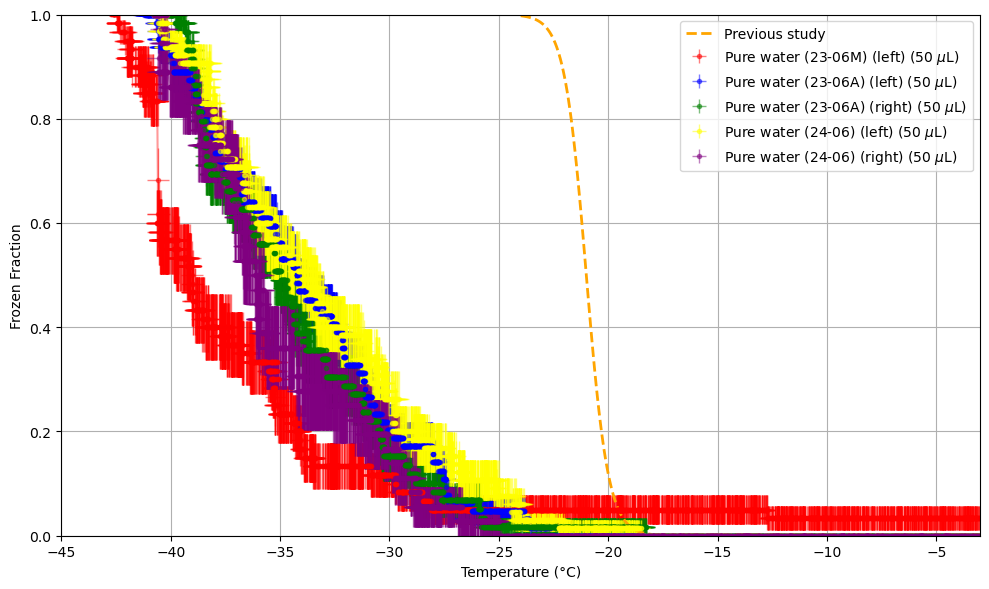

In [5]:
labels = [
        "1_23062026O_purewater_left",
        "1_23062026A_purewater_left",
        "2_23062026A_purewater_right",
        "1_24062026_purewater_left",
        "2_24062026_purewater_right"        
]

color_dict = {
        "1_23062026O_purewater_left": "red",
        "1_23062026A_purewater_left": "blue",
        "2_23062026A_purewater_right": "green",
        "1_24062026_purewater_left": "yellow",
        "2_24062026_purewater_right": "purple"
}

name_dict = {
        "1_23062026O_purewater_left": "Pure water (23-06M) (left) (50 $\mu$L)",
        "1_23062026A_purewater_left": "Pure water (23-06A) (left) (50 $\mu$L)",
        "2_23062026A_purewater_right": "Pure water (23-06A) (right) (50 $\mu$L)",
        "1_24062026_purewater_left": "Pure water (24-06) (left) (50 $\mu$L)",   
        "2_24062026_purewater_right": "Pure water (24-06) (right) (50 $\mu$L)"
}

plot_frozen_fractions(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels},  
    num_droplets=96,  
    time_step=1,  
    V={tag: experiment_data[tag]["volume"] for tag in labels},  
    labels=labels,  
    xlim=(-45, -3),  
    ylim=(0, 1),  
    colors={tag: color_dict[tag] for tag in labels},
    names={tag: name_dict[tag] for tag in labels},
    filename="all_results.pdf"
)

# Cumulative nucleus spectrum:

In [6]:
def cum_inp(frozenwells, num_droplets, V):
    unfrozenwells = num_droplets - frozenwells
    masked = unfrozenwells <=0
    unfrozenwells[masked] = 1e-5 #avoid log(0)
    result = (np.log(num_droplets)-np.log(unfrozenwells))/V
    result[masked] = np.nan #mask those values in plot
    return result


def plot_cumulative_inp(times_dict, temp_dict, num_droplets, time_step, V_dict, labels, xlim, ylim, colors, names, filename=None):
    """
    Plots cumulative INP concentrations with error bars for multiple datasets.
    """

    plt.figure(figsize=(10,12))

    # Iterate over datasets
    for label in labels:
        temp = temp_dict[label]
        times = times_dict[label]
        V = V_dict[label]
        color = colors.get(label)
        name = names.get(label)

        N = len(times) # Set per dataset

        # Initialize frozen wells array
        frozen_wells = np.zeros(len(temp))

        # Update frozen wells for each freezing event
        for i in range(len(times)):
            frozen_wells[int(times[i]):] += 1
        f = frozen_wells/N

        # Calculate cumulative INP concentrations
        k_vals = cum_inp(frozen_wells, N, V)
        mask = f>0.03
        k_vals[~mask] = np.nan
        # Calculate error in K
        df = 1/((1-f)*V)
        dV = -k_vals/V
        uf = u_f(f,N)
        uV = 0.52e-6
        uk = np.sqrt((df*uf)**2 + (dV*uV)**2)
        
        # Temp uncertainty
        uT = u_temp(temp)
        
        # Plot main line
        plt.plot(temp, k_vals, color=color, linewidth=1.2, alpha=0.4)
        
        # Plot errorbars
        plt.errorbar(temp,k_vals,xerr=uT,yerr=uk,fmt='o',color=color,markersize=1,linewidth=0,elinewidth=1,alpha=0.5,capsize=0,label=name)
        

    # Customize plot
    plt.xlabel("Temperature (°C)", fontsize=12)
    plt.ylabel("Cumulative INP concentration (L$^{-1}$ water)", fontsize=12)
    plt.legend(loc="best", fontsize=6, markerscale=6)
    plt.yscale('log')
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True, linestyle="--", alpha=0.7)

    # Save or show the plot
    if filename:
        plt.savefig(filename)
    plt.show(),


C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\2722248365.py:40: RuntimeWarning: divide by zero encountered in divide
  df = 1/((1-f)*V)
C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\2722248365.py:44: RuntimeWarning: invalid value encountered in multiply
  uk = np.sqrt((df*uf)**2 + (dV*uV)**2)


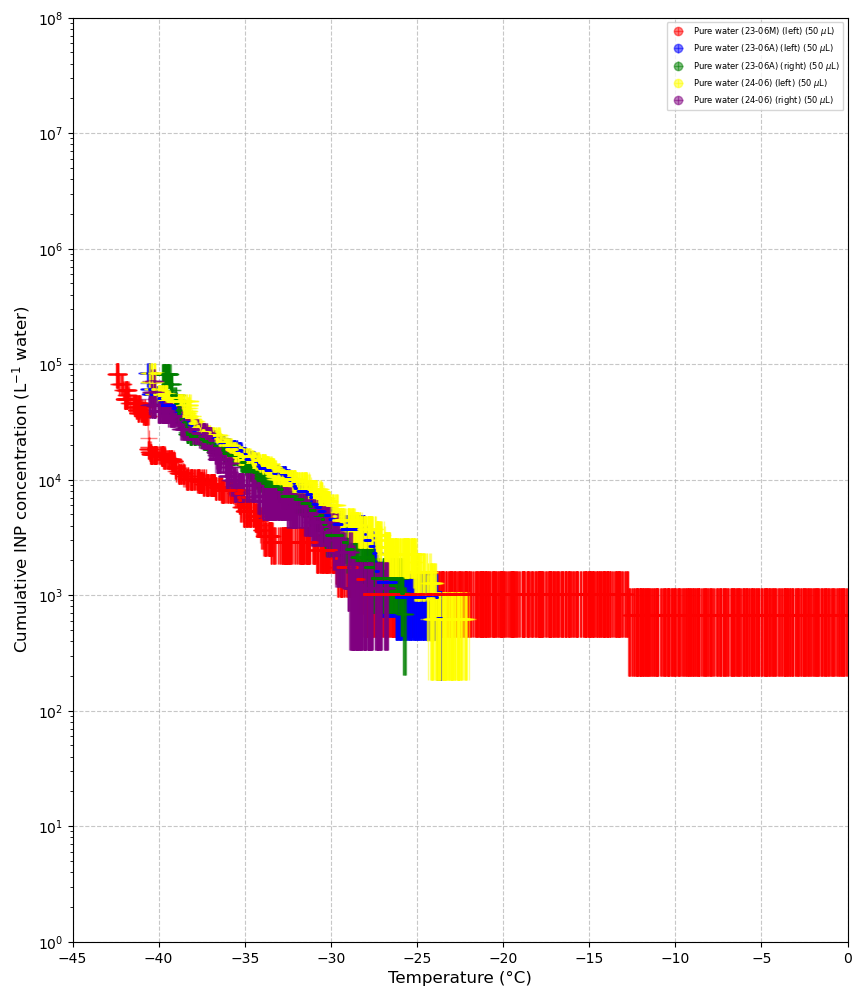

In [7]:
plot_cumulative_inp(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels},  
    num_droplets=96,  
    time_step=1,  
    V_dict={tag: experiment_data[tag]["volume"] for tag in labels},  
    labels=labels,  
    xlim=(-45,0),  
    ylim=(1e0, 1e8),  
    colors={tag: color_dict[tag] for tag in labels}, 
    names={tag: name_dict[tag] for tag in labels}, 
    filename = "cum_inp.pdf"
)

# Mean and onset freezing temperatures 

In [8]:
def freezing_point_and_onset(times_dict, temp_dict, V_dict, time_step, labels, colors, xlim=None, ylim=None, filename=None):
    """
    Gives mean freezing point and onset freezing temperature for multiple datasets
    """
    all_freezing_temps = []
    
    # Iterate over datasets
    for i, label in enumerate(labels):
        temp = temp_dict[label]
        times = times_dict[label]
        V = V_dict[label]
        
        freezing_temps = temp[times]

        # Remove first datapoint
        if i == 0:
            freezing_temps = freezing_temps[2:]
        
        # voeg toe aan totale lijs
        all_freezing_temps.extend(freezing_temps)
        
        # Calculate mean and standard deviation
        mean_freezing = np.mean(freezing_temps)
        std_freezing = np.std(freezing_temps)

        print(f"Mean freezing point for {label}: {mean_freezing:.2f} °C") #50microliter
        print(f"Standard deviation for {label}: {std_freezing:.2f} °C")

        #getting onset temp 
        print(f"Onset freezing temp for {label} is: {freezing_temps[0]} °C")
        print()

# Used this specific code to calculate the average onset freezing point for my data, where 1 point was excluded because it was non-physical

In [9]:
def freezing_point_and_onset(times_dict, temp_dict, V_dict, time_step, labels, colors,
                             xlim=None, ylim=None, filename=None):

    all_freezing_temps = []

    # Make subplots (2 rows, 3 columns)
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    axs = axs.flatten()

    # Use same bins for every plot
    bins = np.arange(-40, -15, 1)

    for i, label in enumerate(labels):

        temp = temp_dict[label]
        times = times_dict[label]

        freezing_temps = temp[times]

        # remove non-physical datapoints
        if i == 0:
            freezing_temps = freezing_temps[2:]

        all_freezing_temps.extend(freezing_temps)

        # calculations
        mean_freezing = np.mean(freezing_temps)
        std_freezing = np.std(freezing_temps)

        print(f"Mean freezing point for {label}: {mean_freezing:.2f} °C")
        print(f"Standard deviation for {label}: {std_freezing:.2f} °C")
        print(f"Onset freezing temp for {label}: {freezing_temps[0]:.2f} °C\n")

        # Histogram
        ax = axs[i]

        ax.hist(
            freezing_temps,
            bins=bins,
            color=colors[label],
            edgecolor="black",
            alpha=0.8
        )

        # pointing out average 
        ax.axvline(mean_freezing,
                   color="red",
                   linestyle="--",
                   linewidth=2,
                   label="Mean")

        # plotting sigma in corner
        ax.text(
            0.95, 0.95,
            rf"$\sigma$ = {std_freezing:.2f} °C",
            transform=ax.transAxes,
            ha="right",
            va="top",
            bbox=dict(facecolor="white", edgecolor="black")
        )

        ax.set_title(label)
        ax.set_xlabel("Freezing temperature (°C)")
        ax.set_ylabel("Number of droplets")

    # Remove last subplot (I only have 5)
    axs[-1].axis("off")

    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi = 300, bbox_inches="tight")

    plt.show()

Mean freezing point for 1_23062026O_purewater_left: -37.59 °C
Standard deviation for 1_23062026O_purewater_left: 4.93 °C
Onset freezing temp for 1_23062026O_purewater_left: -12.75 °C

Mean freezing point for 1_23062026A_purewater_left: -33.82 °C
Standard deviation for 1_23062026A_purewater_left: 4.64 °C
Onset freezing temp for 1_23062026A_purewater_left: -22.67 °C

Mean freezing point for 2_23062026A_purewater_right: -34.29 °C
Standard deviation for 2_23062026A_purewater_right: 4.46 °C
Onset freezing temp for 2_23062026A_purewater_right: -18.27 °C

Mean freezing point for 1_24062026_purewater_left: -33.21 °C
Standard deviation for 1_24062026_purewater_left: 5.07 °C
Onset freezing temp for 1_24062026_purewater_left: -18.60 °C

Mean freezing point for 2_24062026_purewater_right: -35.14 °C
Standard deviation for 2_24062026_purewater_right: 4.08 °C
Onset freezing temp for 2_24062026_purewater_right: -24.97 °C



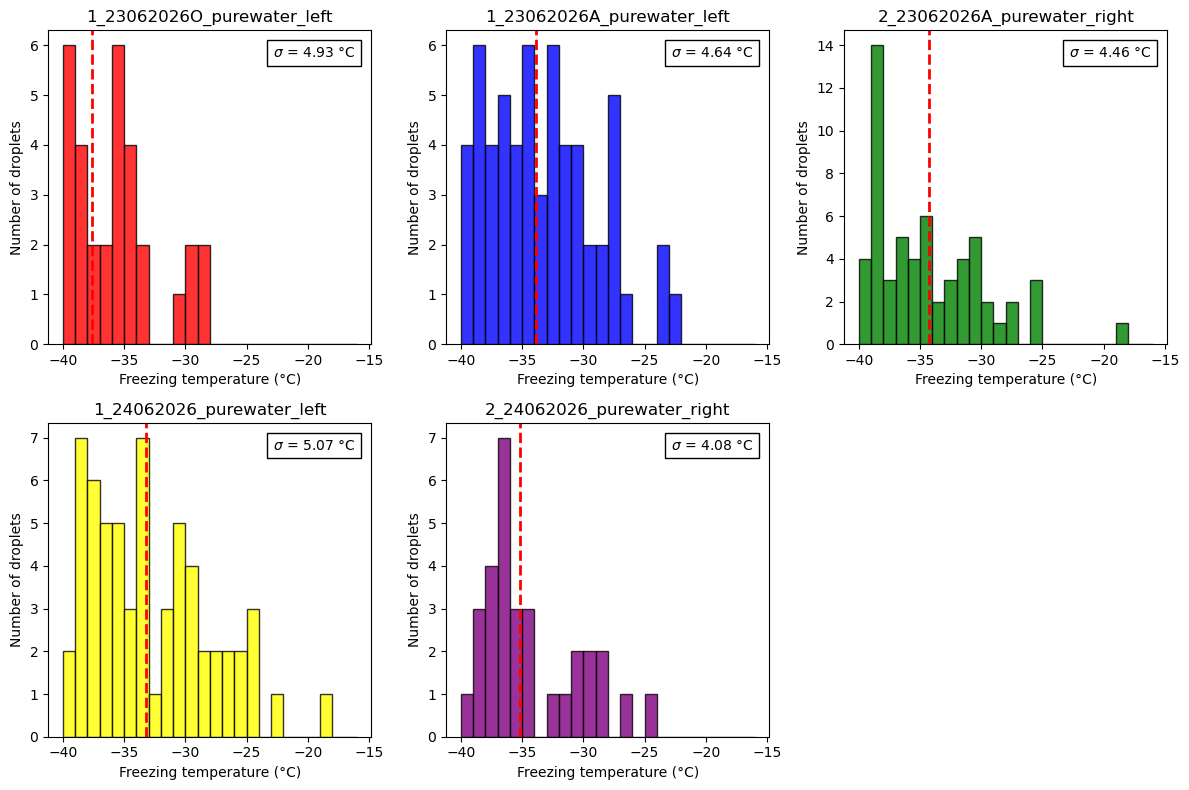

In [10]:
freezing_point_and_onset(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels}, 
    V_dict={tag: experiment_data[tag]["volume"] for tag in labels},  
    time_step=1,  
    labels=labels,  
    xlim=(-40, 0),  
    ylim=(1e-1, 1/(100e-9)),  
    colors={tag: color_dict[tag] for tag in labels},
    filename = "freezing_histograms.pdf"
)

# Homogeneous nucleation rate 

In [11]:
# Constants
T0 = 273.15         # Reference temperature in Kelvin (0°C)
lf = 3.3355 * 10**5    # Latent heat of fusion in J/kg
k = 1.3806 * 10**-23  # Boltzmann constant in J/K
K = float(10**47)   # Prefactor in 1/cm^3s
g_para = 2.591893*10**-20  # From Ickes paper method 
a1 = 0.9167
a2 = -1.75*10**-4
a3 = -5*10**-7
M = 18.015         # Molar mass of water g/mol
N = 6.02214 * 10**23  # Avogadro's number 
rv = 461.5         # Specific gas constant for water vapor
arrayt = np.arange(240,275)  # Temperature range in Kelvin

# Compute supercooling temperature
Tc = arrayt - T0

# Specific volume of ice (m³)
def Vice(T):
    Tc = T - T0
    return (M / ((a1 + a2 * Tc + a3 * Tc**2) * N)) * 10**-6

# Supersaturation ratio
def si(T):
    return lf / (rv * T0) * (T0 / T - 1)

# Surface tension (J/m²), from fitted data
sigma = (29.1 * 10**-3 + 0.1240907 * 10**-3 * Tc)

# Gibbs Free Energy Barrier calculation (J)
def G_barrier(T):
    return (16 * np.pi / 3) * (Vice(T)**2 * (sigma**3)) / ((k * T * si(T))**2)

# Theoretical nucleation rate
# def ln_J(T):
#     G_barrier_T = G_barrier(T)
#     return 10**((np.log(K) - G_barrier_T / (k * T) - g_para / (k * T)) / np.log(10))
def J_theoretical(T):
    G_barrier_T = G_barrier(T)  # Compute Gibbs free energy barrier
    return K * np.exp(-G_barrier_T / (k * T) - g_para / (k * T))


# # Logarithm of theoretical nucleation rate
# def J_theoretical(T):
#     G_barrier_T = G_barrier(T)  # Compute Gibbs free energy barrier
#     J_values = K * np.exp(-G_barrier_T / (k * T) - g_para / (k * T))
#     return J_values

# Function for experimental nucleation rate calculation
def J(frozen_fractions, V, time_step):
    j = []  
    threshold = 0.01  # Define the threshold
    
    for i in range(len(frozen_fractions)):
        if np.isclose(frozen_fractions[i], 1, atol=threshold) or np.isclose(frozen_fractions[i], 0, atol=threshold):
            j.append(np.nan)
        else:
            j_value = -np.log(1 - frozen_fractions[i]) / (V * time_step)
            j.append(j_value)
    
    return np.array(j)

# Error calculation for experimental nucleation rate
def error_J(frozen_fractions, V, time_step, N):
    J_values = J(frozen_fractions, V, time_step)

    uf = np.sqrt(frozen_fractions*(1-frozen_fractions)/N)
    uV = 0.52e-6 # mu L

    df = 1/((1-frozen_fractions)*V*time_step)
    dV = -J_values/V

    uJ = np.sqrt((df*uf)**2 + (dV*uV)**2)

    #prevent issues at f=0 or f=1
    mask = np.isnan(J_values)
    uJ[mask] = np.nan
    return uJ

def homogeneous_nucleation_rate(times_dict, temp_dict, num_droplets, V_dict, time_step, labels, colors, names, xlim=None, ylim=None, filename=None):
    """
    Plots experimental nucleation rates and overlays the theoretical values.
    """
    plt.figure(figsize=(10, 6))

    # Plot experimental data
    for idx, label in enumerate(labels):
        times = times_dict[label]
        temp = temp_dict[label]  # Assuming this is in Celsius
        V = V_dict[label]
        color = colors.get(label)
        name = names.get(label)
        N = len(times)

        # Compute frozen fraction
        frozen_fractions = np.zeros(len(temp))
        for i in range(len(times)):
            frozen_fractions[int(times[i]):] += 1 / N
            valid_mask = (frozen_fractions > 0.03) #& (frozen_fractions < 0.97)

        uT = u_temp(temp)
        
        j_values = J(frozen_fractions, V, time_step)
        j_values[~valid_mask] = np.nan
        uJ = error_J(frozen_fractions, V, time_step, N)
        uJ[~valid_mask] = np.nan

        plt.plot(temp,j_values,color=color,linewidth=1,alpha=0.4)
        plt.errorbar(temp,j_values,xerr=uT,yerr=uJ,fmt='o',color=color,markersize=1,linewidth=0,elinewidth=1,alpha=0.5,capsize=0,label=name)

    # Overlay theoretical nucleation rate (now correctly in log10 scale)
    plt.plot(arrayt - T0, J_theoretical(arrayt), label="Theoretical Nucleation Rate", linestyle="--", color="black")

    # Plot customization
    plt.xlabel('Temperature (°C)', fontsize=12)
    plt.ylabel('Nucleation Rate (1/(s·L))', fontsize=12)  # Fixed label
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Save or show the plot
    if filename:
        plt.savefig(filename)
    plt.show()


C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\535769458.py:67: RuntimeWarning: invalid value encountered in sqrt
  uf = np.sqrt(frozen_fractions*(1-frozen_fractions)/N)
C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\535769458.py:70: RuntimeWarning: divide by zero encountered in divide
  df = 1/((1-frozen_fractions)*V*time_step)
C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\535769458.py:73: RuntimeWarning: invalid value encountered in multiply
  uJ = np.sqrt((df*uf)**2 + (dV*uV)**2)
C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\535769458.py:122: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\535769458.py:126: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(filename)
C:\Users\lucas\AppData\Local\Temp\ipykernel_14080\535769458.py:126: UserWarning: Creating legend with loc="best" can be slow with large amounts of data

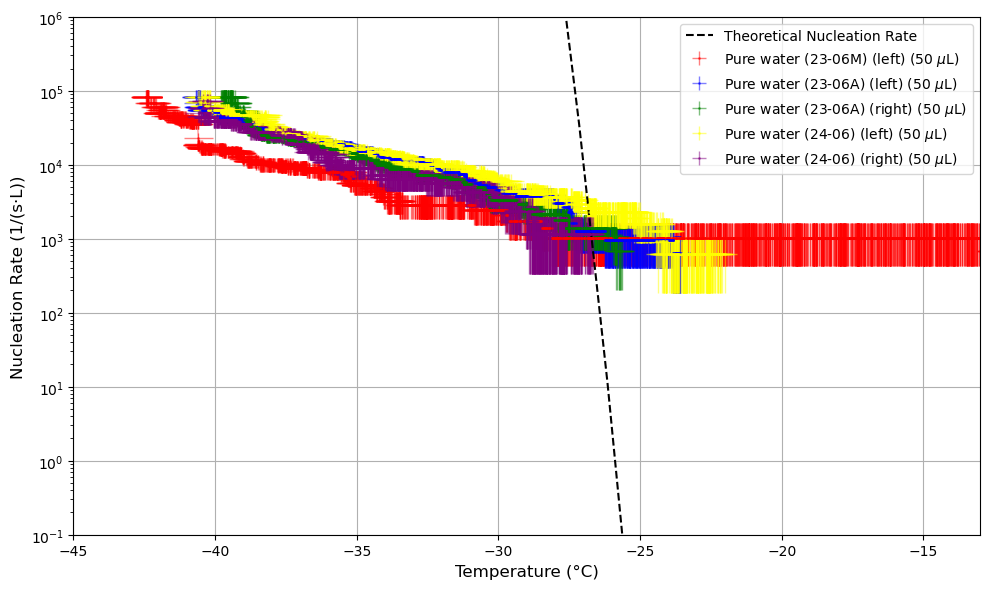

In [12]:
homogeneous_nucleation_rate(
    times_dict={tag: experiment_data[tag]["times"] for tag in labels},  
    temp_dict={tag: experiment_data[tag]["temps"] for tag in labels},  
    num_droplets=96,  
    time_step=1,  
    V_dict={tag: experiment_data[tag]["volume"] for tag in labels},  
    labels=labels,  
    xlim=(-45,-13),  
    ylim=(1e-1, 1e6),  
    colors={tag: color_dict[tag] for tag in labels}, 
    names={tag: name_dict[tag] for tag in labels}, 
    filename = "homogeneous_nucleation_rate.pdf"
)